# eBFE 2D Breakout Geometry Preparation

Prepare a contained HUC12 breakout from Upper Guadalupe 3 plan 08. This example qualifies the parent, clones plan/geometry/unsteady associations, trims mesh-owned features, regenerates the cloned mesh, and reviews parent-face flux locations.

**Boundary contract:** existing boundary data are inventoried and the unsteady file is cloned byte-for-byte. This notebook does **not** author, relocate, reinterpret, or run any breakout boundary condition, and it never computes a hydraulic plan.

## Engineering review sequence

1. Confirm that plan 08 is a pure 2D, unsteady model and the HUC12 is contained.
2. Review retained, clipped, dropped, and intentionally preserved geometry features.
3. Optionally clone and remesh in an isolated working copy.
4. Verify plan associations and the complete unsteady-file digest.
5. Map candidate parent-face flux locations for future boundary-condition design.
6. Record existing forcing and unresolved proposed breakout boundary locations as **Next Steps**.

The default committed state is read-only. Set `RAS_COMMANDER_APPLY_BREAKOUT_GEOMETRY=1` only after providing a disposable project copy in `RAS_COMMANDER_BREAKOUT_WORKING_PROJECT`.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from ras_commander import (
    Breakout2DSpec,
    RasBreakout2D,
    RasPrj,
    init_ras_project,
)

REPO_ROOT = Path.cwd() if (Path.cwd() / "examples").is_dir() else Path.cwd().parent
BOUNDARY_PATH = REPO_ROOT / "examples" / "data" / "956_huc12_121002010305.geojson"
SOURCE_PROJECT = Path(os.environ["RAS_COMMANDER_EBFE_UPGU3_PROJECT"])
WORKING_VALUE = os.getenv("RAS_COMMANDER_BREAKOUT_WORKING_PROJECT", "").strip()
WORKING_PROJECT = Path(WORKING_VALUE) if WORKING_VALUE else None
APPLY_GEOMETRY_PREPARATION = os.getenv(
    "RAS_COMMANDER_APPLY_BREAKOUT_GEOMETRY", "0"
).strip() == "1"
RAS_VERSION = os.getenv("RAS_COMMANDER_HECRAS_VERSION", "6.6")

assert SOURCE_PROJECT.is_dir(), SOURCE_PROJECT
assert BOUNDARY_PATH.is_file(), BOUNDARY_PATH
if APPLY_GEOMETRY_PREPARATION:
    assert WORKING_PROJECT is not None and WORKING_PROJECT.is_dir()
    assert SOURCE_PROJECT.resolve() != WORKING_PROJECT.resolve()

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)
print(f"Source: {SOURCE_PROJECT}")
print(f"Geometry preparation enabled: {APPLY_GEOMETRY_PREPARATION}")

Source: C:\Users\billk_clb\Documents\Codex\2026-08-28\one-of-the-things-that-we\model_workspaces\upgu3-face-flow-parent
Geometry preparation enabled: False


In [2]:
source_ras = RasPrj()
init_ras_project(
    SOURCE_PROJECT,
    RAS_VERSION,
    ras_object=source_ras,
    load_results_summary=False,
    hide_intro=True,
)

spec = Breakout2DSpec(
    source_plan="08",
    source_2d_area="UPGU3_2DArea",
    child_boundary=BOUNDARY_PATH,
    breakout_id="HUC12-121002010305",
)
preflight = RasBreakout2D.preflight(spec, ras_object=source_ras)
assert preflight.is_ready, preflight.blocking_issues

summary = pd.DataFrame(
    [
        ("Source plan", "p08"),
        ("Geometry / unsteady", f"g{preflight.source_geometry_number} / u{preflight.source_unsteady_number}"),
        ("Plan classification", "unsteady_2d / pure 2D"),
        ("2D flow area", spec.source_2d_area),
        ("Base cell size", f"{preflight.base_cell_size:,.0f} ft"),
        ("Child area", f"{preflight.child_boundary.geometry.iloc[0].area / 27_878_400:,.2f} sq mi"),
        ("Blocking checks passed", f"{int(preflight.checks['passed'].sum())} / {len(preflight.checks)}"),
        ("Hydraulic computation", "NOT RUN"),
        ("Boundary authoring", "NOT PERFORMED"),
    ],
    columns=["review_item", "value"],
)
display(summary)
display(preflight.checks[["check_id", "passed", "blocking", "message"]])

,review_item,value
0,Source plan,p08
1,Geometry / unsteady,g01 / u01
2,Plan classification,unsteady_2d / pure 2D
3,2D flow area,UPGU3_2DArea
4,Base cell size,200 ft
5,Child area,24.73 sq mi
6,Blocking checks passed,6 / 6
7,Hydraulic computation,NOT RUN
8,Boundary authoring,NOT PERFORMED


,check_id,passed,blocking,message
0,pure_2d_plan,True,True,Source plan must be classified as valid unsteady pure 2D
1,single_2d_flow_area,True,True,Initial breakout preparation requires exactly one 2D flow area
2,unsupported_structures_absent,True,True,Initial 2D breakout preparation does not support 1D or structure elements
3,child_within_parent,True,True,Child boundary must be contained by the parent 2D area
4,boundary_partition_closes,True,True,Inherited and artificial segments must close the child perimeter
5,reference_points_do_not_require_trim,True,True,Reference points requiring trim are outside the initial implementation


<ipython-input-1-b0d6732f2361>:119: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,terrain_source,terrain_metric,result_source,inundation_definition,parent_cells,wet_cells,wet_cell_fraction
0,UPGU3.g01.hdf,minimum terrain elevation at parent mesh cells,UPGU3.p08.hdf,parent p08 maximum depth > 0.1 ft,295111,292677,0.991752


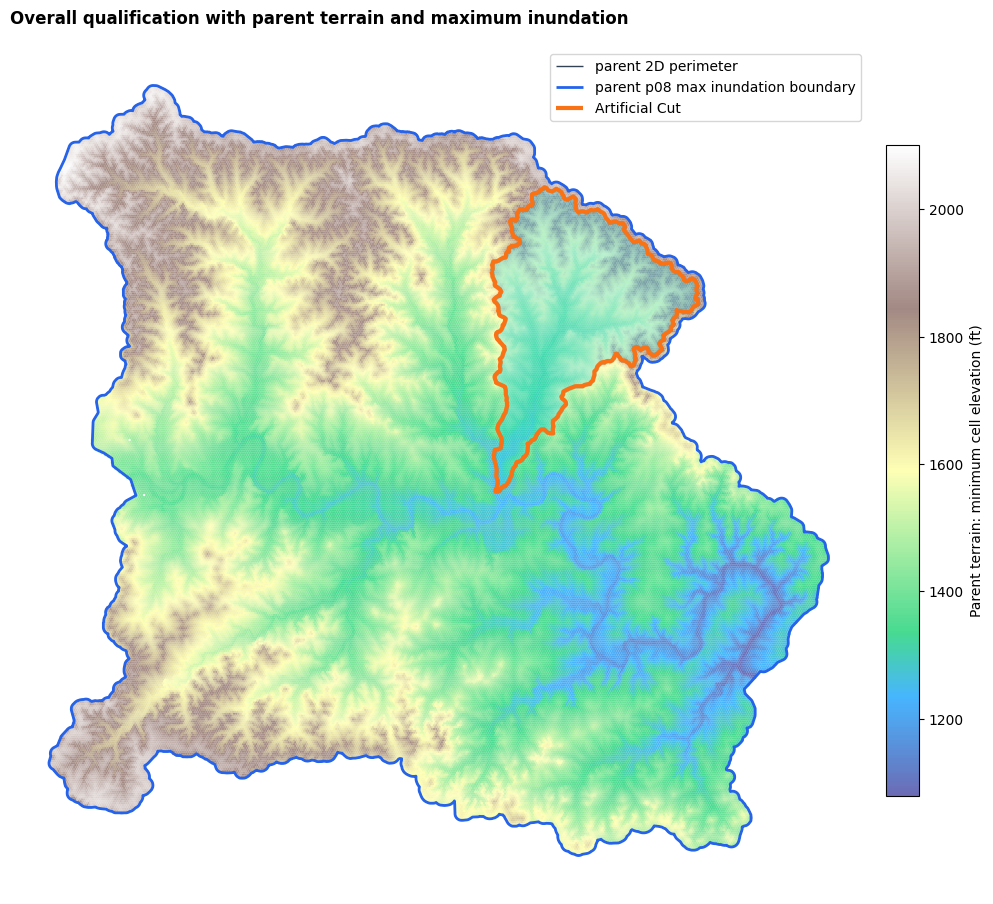

In [3]:
from shapely import concave_hull, contains_xy
from shapely.geometry import MultiPoint

from ras_commander import HdfMesh, HdfResultsMesh

parent_topology = HdfMesh.get_mesh_sloped_topology(
    preflight.source_geometry_hdf,
    spec.source_2d_area,
)
parent_max_ws = HdfResultsMesh.get_mesh_max_ws(preflight.source_plan_hdf)
parent_max_ws = (
    parent_max_ws[parent_max_ws["mesh_name"] == spec.source_2d_area]
    .set_index("cell_id")
    .reindex(np.arange(parent_topology["n_cells"]))
)

parent_cell_xy = parent_topology["cell_centers"]
parent_terrain = gpd.GeoDataFrame(
    {
        "cell_id": np.arange(parent_topology["n_cells"]),
        "minimum_terrain_elevation": parent_topology["cell_min_elev"],
        "maximum_water_surface": parent_max_ws["maximum_water_surface"].to_numpy(),
    },
    geometry=gpd.points_from_xy(parent_cell_xy[:, 0], parent_cell_xy[:, 1]),
    crs=preflight.parent_boundary.crs,
)
parent_terrain["maximum_depth"] = (
    parent_terrain["maximum_water_surface"]
    - parent_terrain["minimum_terrain_elevation"]
)
wet_mask = (
    np.isfinite(parent_terrain["maximum_depth"])
    & (parent_terrain["maximum_depth"] > 0.1)
)
wet_xy = parent_cell_xy[wet_mask.to_numpy()]
inundation_geometry = (
    concave_hull(MultiPoint(wet_xy), ratio=0.05, allow_holes=True)
    .buffer(preflight.base_cell_size * 0.75)
    .intersection(preflight.parent_boundary.geometry.iloc[0])
)
parent_inundation = gpd.GeoDataFrame(
    {"source": ["parent p08 maximum WSE; depth > 0.1 ft"]},
    geometry=[inundation_geometry],
    crs=preflight.parent_boundary.crs,
)
child_terrain_mask = contains_xy(
    preflight.child_boundary.geometry.iloc[0],
    parent_cell_xy[:, 0],
    parent_cell_xy[:, 1],
)

parent_context_summary = pd.DataFrame(
    [{
        "terrain_source": preflight.source_geometry_hdf.name,
        "terrain_metric": "minimum terrain elevation at parent mesh cells",
        "result_source": preflight.source_plan_hdf.name,
        "inundation_definition": "parent p08 maximum depth > 0.1 ft",
        "parent_cells": len(parent_terrain),
        "wet_cells": int(wet_mask.sum()),
        "wet_cell_fraction": float(wet_mask.mean()),
    }]
)
display(parent_context_summary)

fig, ax = plt.subplots(figsize=(12, 11))
terrain_artist = ax.hexbin(
    parent_cell_xy[:, 0],
    parent_cell_xy[:, 1],
    C=parent_terrain["minimum_terrain_elevation"],
    reduce_C_function=np.mean,
    gridsize=350,
    mincnt=1,
    cmap="terrain",
    linewidths=0,
    alpha=0.72,
)
preflight.parent_boundary.boundary.plot(
    ax=ax,
    color="#334155",
    linewidth=1.0,
    label="parent 2D perimeter",
)
parent_inundation.boundary.plot(
    ax=ax,
    color="#2563eb",
    linewidth=2.0,
    label="parent p08 max inundation boundary",
)
preflight.child_boundary.plot(
    ax=ax,
    facecolor="#22d3ee",
    edgecolor="#0e7490",
    alpha=0.3,
    linewidth=2.5,
)
colors = {"inherited": "#16a34a", "artificial_cut": "#f97316"}
for segment_type, frame in preflight.boundary_segments.groupby("segment_type"):
    frame.plot(
        ax=ax,
        color=colors[segment_type],
        linewidth=3.0,
        label=segment_type.replace("_", " ").title(),
    )
fig.colorbar(
    terrain_artist,
    ax=ax,
    fraction=0.035,
    pad=0.02,
    label="Parent terrain: minimum cell elevation (ft)",
)
ax.set_title(
    "Overall qualification with parent terrain and maximum inundation",
    loc="left",
    weight="bold",
)
ax.set_aspect("equal")
ax.legend(loc="upper right")
ax.set_axis_off()
plt.show()

<ipython-input-1-f77311fc02f7>:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,feature_type,action,count
0,bc_line,preserve,4
1,breakline,clip,10
2,breakline,drop,1534
3,breakline,keep,132
4,mesh_area,replace,1
5,reference_line,clip,1
6,reference_line,drop,13
7,reference_line,keep,1
8,refinement_region,drop,1
9,unsteady_boundary,preserve,4


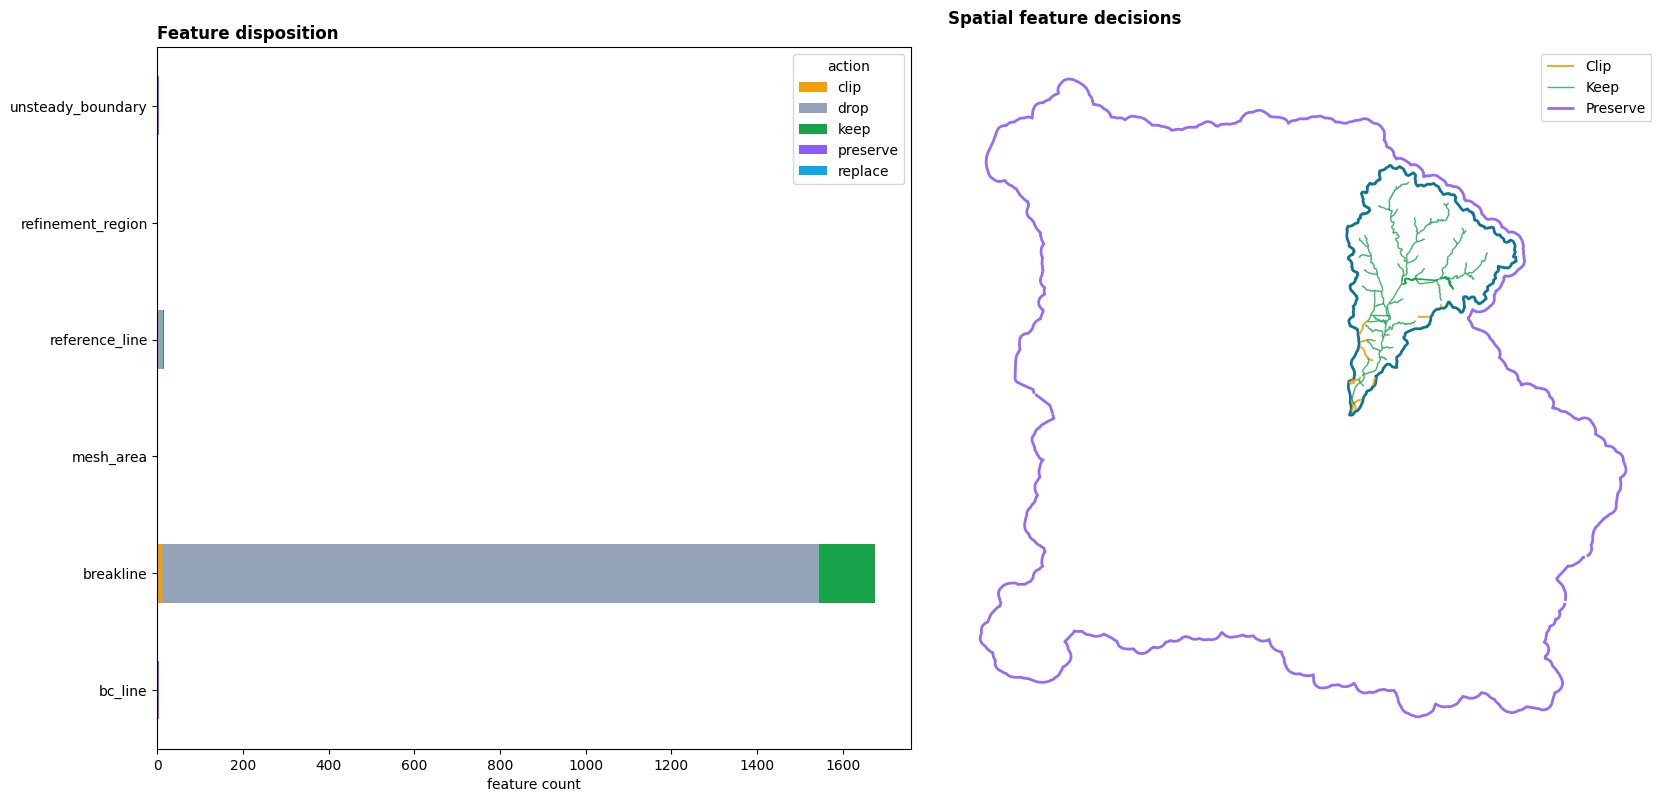

In [4]:
action_counts = (
    preflight.feature_actions.groupby(["feature_type", "action"])
    .size()
    .rename("count")
    .reset_index()
)
display(action_counts)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
pivot = action_counts.pivot(index="feature_type", columns="action", values="count").fillna(0)
pivot.plot(kind="barh", stacked=True, ax=axes[0], color={"keep": "#16a34a", "clip": "#f59e0b", "drop": "#94a3b8", "replace": "#0ea5e9", "preserve": "#8b5cf6"})
axes[0].set_title("Feature disposition", loc="left", weight="bold")
axes[0].set_xlabel("feature count")
axes[0].set_ylabel("")

preflight.child_boundary.boundary.plot(ax=axes[1], color="#0e7490", linewidth=2.0)
style = {"drop": ("#94a3b8", 0.12, 0.4), "keep": ("#16a34a", 0.8, 1.0), "clip": ("#f59e0b", 0.9, 1.4), "preserve": ("#8b5cf6", 0.9, 2.0)}
for action, frame in preflight.feature_actions.groupby("action"):
    spatial = frame[frame.geometry.notna() & ~frame.geometry.is_empty]
    if spatial.empty or action not in style:
        continue
    color, alpha, width = style[action]
    spatial.plot(ax=axes[1], color=color, alpha=alpha, linewidth=width, label=action.title())
axes[1].set_title("Spatial feature decisions", loc="left", weight="bold")
axes[1].set_aspect("equal")
axes[1].set_axis_off()
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

## Existing boundary inputs - inventory only

These are the rows attached to the source plan's single unsteady file. They remain parent-model inputs; the geometry-only clone does not make them valid breakout boundaries. The complete cloned `u##` file must retain the same SHA-256 digest as the source.

In [5]:
existing_boundaries = preflight.existing_boundaries.copy()
existing_boundaries.insert(0, "source_plan", "p08")
existing_boundaries.insert(1, "unsteady_file", preflight.source_unsteady_path.name)
display(existing_boundaries)

boundary_actions = preflight.feature_actions[
    preflight.feature_actions["feature_type"].isin(["bc_line", "unsteady_boundary"])
][["feature_type", "name", "action", "reason"]]
assert set(boundary_actions["action"]) == {"preserve"}
display(boundary_actions)

,source_plan,unsteady_file,unsteady_number,boundary_condition_number,river_reach_name,river_station,storage_area_name,pump_station_name,area_2d,bc_line_name,bc_type,hydrograph_type,Interval,Stage Hydrograph TW Check,Flow Hydrograph Slope,DSS File,DSS Path,Use DSS,Use Fixed Start Time,Fixed Start Date/Time,Is Critical Boundary,Critical Boundary Flow,dss_part_a,dss_part_b,dss_part_c,dss_part_d,dss_part_e,dss_part_f,hydrograph_num_values,Friction Slope,friction_slope_value,critical_fallback_flag,full_path,Flow Title,Program Version,Use Restart,Precipitation Mode,Wind Mode,Met BC=Precipitation|Mode,Met BC=Evapotranspiration|Mode,Met BC=Precipitation|Expanded View,Met BC=Precipitation|Constant Units,Met BC=Precipitation|Gridded Source,description
0,p08,UPGU3.u01,01,1,,,,,UPGU3_2DArea,Inflow_from_UPGU2,Flow Hydrograph,Flow Hydrograph,15MIN,0,0.0027,.\DSS Inputs\UPGU2.dss,/REFERENCE LINES/UPGU2_2DArea: UPGU2_TransferLine/FLOW/01Dec2019-01Jan2020/30Minute/1pct/,True,False,",",False,,REFERENCE LINES,UPGU2_2DArea: UPGU2_TransferLine,FLOW,01Dec2019-01Jan2020,30Minute,1pct,0,NaN,NaN,NaN,C:\Users\billk_clb\Documents\Codex\2026-08-28\one-of-the-things-that-we\model_workspaces\upgu3-f...,1pct,6.31,0,Enable,No Wind Forces,Gridded,None,-1,mm/hr,DSS,
1,p08,UPGU3.u01,01,2,,,,,UPGU3_2DArea,Outflow_to_UPGU4,Normal Depth,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,"0.0014,0",0.0014,0.0,C:\Users\billk_clb\Documents\Codex\2026-08-28\one-of-the-things-that-we\model_workspaces\upgu3-f...,1pct,6.31,0,Enable,No Wind Forces,Gridded,None,-1,mm/hr,DSS,
2,p08,UPGU3.u01,01,3,,,,,UPGU3_2DArea,BC_1,Normal Depth,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,"0.001,0",0.0010,0.0,C:\Users\billk_clb\Documents\Codex\2026-08-28\one-of-the-things-that-we\model_workspaces\upgu3-f...,1pct,6.31,0,Enable,No Wind Forces,Gridded,None,-1,mm/hr,DSS,
3,p08,UPGU3.u01,01,4,,,,,UPGU3_2DArea,BC_2,Normal Depth,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,"0.001,0",0.0010,0.0,C:\Users\billk_clb\Documents\Codex\2026-08-28\one-of-the-things-that-we\model_workspaces\upgu3-f...,1pct,6.31,0,Enable,No Wind Forces,Gridded,None,-1,mm/hr,DSS,


,feature_type,name,action,reason
0,bc_line,Inflow_from_UPGU2,preserve,boundary_condition_scope_deferred
1,bc_line,BC_1,preserve,boundary_condition_scope_deferred
2,bc_line,Outflow_to_UPGU4,preserve,boundary_condition_scope_deferred
3,bc_line,BC_2,preserve,boundary_condition_scope_deferred
1697,unsteady_boundary,Inflow_from_UPGU2,preserve,cloned_byte_identical_boundary_scope_deferred
1698,unsteady_boundary,Outflow_to_UPGU4,preserve,cloned_byte_identical_boundary_scope_deferred
1699,unsteady_boundary,BC_1,preserve,cloned_byte_identical_boundary_scope_deferred
1700,unsteady_boundary,BC_2,preserve,cloned_byte_identical_boundary_scope_deferred


## Optional geometry-only preparation

The following cell is the complete mutation boundary. It clones geometry, unsteady flow, and plan associations in the isolated working project; registers the cloned geometry in RASMapper; replaces the cloned perimeter and mesh-owned features; imports the edited text into the cloned HDF; and regenerates the cloned mesh. It does not call `RasCmdr.compute_plan` or any other hydraulic solver entry point.

In [6]:
clone = None
preparation = None
if APPLY_GEOMETRY_PREPARATION:
    working_ras = RasPrj()
    init_ras_project(
        WORKING_PROJECT,
        RAS_VERSION,
        ras_object=working_ras,
        load_results_summary=False,
        hide_intro=True,
    )
    clone = RasBreakout2D.clone_plan_components(
        preflight,
        ras_object=working_ras,
        plan_title="HUC12 breakout geometry prep",
        plan_short_id="HUC12_PREP",
        geometry_title="HUC12 breakout geometry",
    )
    preparation = RasBreakout2D.prepare_cloned_geometry(
        preflight,
        clone,
        ras_object=working_ras,
        refresh_hdf=True,
        remesh=True,
        compute_property_tables=False,
        timeout=1200,
    )
    assert clone.boundaries_unchanged
    assert preparation.boundaries_unchanged
    display(
        pd.DataFrame(
            [{
                "plan": f"p{clone.plan_number}",
                "geometry": f"g{clone.geometry_number}",
                "unsteady": f"u{clone.unsteady_number}",
                "unsteady_sha256": clone.cloned_unsteady_sha256,
                "mesh_ok": preparation.mesh_result.ok,
                "containment_ok": preparation.containment_result.ok,
                "hydraulic_compute": False,
            }]
        )
    )
else:
    display(Markdown(
        "**Read-only review mode.** Set the two working-project environment variables "
        "documented above to execute the clone/trim/remesh cell in a disposable copy."
    ))

**Read-only review mode.** Set the two working-project environment variables documented above to execute the clone/trim/remesh cell in a disposable copy.

## Parent-face flux locations

This is a read-only review of the already-computed parent p08 result. Positive flow is oriented outward from the proposed child; adjacent significant faces with the same dominant direction are grouped only to make candidate locations legible. These zones are **not** boundary-condition records.

In [7]:
flux = RasBreakout2D.review_parent_boundary_flux(
    preflight,
    minimum_peak_flow=100.0,
    minimum_volume_fraction=0.0001,
    gap_multiplier=3.0,
)

flux_summary = pd.DataFrame(
    [{
        "flow_source": flux.source,
        "units": flux.units or "cfs",
        "cut_faces": len(flux.faces),
        "significant_faces": int(flux.faces["significant"].sum()),
        "candidate_zones": len(flux.zones),
        "boundary_records_created": 0,
    }]
)
display(flux_summary)
display(flux.zones.drop(columns="geometry"))

,flow_source,units,cut_faces,significant_faces,candidate_zones,boundary_records_created
0,native_face_flow,cfs,1051,51,22,0


,zone_id,dominant_direction,face_count,face_ids,peak_flow,peak_abs_flow,absolute_volume_fraction,arrow_dx,arrow_dy
0,FLUX-001,inflow,1,[233421],-2721.547119,2721.547119,0.006661,0.000000,-1.000000
1,FLUX-002,outflow,1,[234671],719.005493,719.005493,0.002386,-1.000000,0.000000
2,FLUX-003,inflow,4,"[234677, 235744, 234642, 236914]",-13488.601944,13488.601944,0.033551,0.316228,-0.948683
3,FLUX-004,outflow,1,[245674],185.765167,185.765167,0.000559,-0.432456,-0.901655
4,FLUX-005,inflow,1,[246774],-147.977173,147.977173,0.000606,0.970603,-0.240685
5,FLUX-006,inflow,1,[246821],191.552246,191.552246,0.000686,0.856138,0.516747
6,FLUX-007,outflow,6,"[250001, 250002, 251061, 251062, 251063, 251064]",2623.394371,2623.394371,0.006990,-0.763592,-0.645699
7,FLUX-008,inflow,1,[251145],-1055.620850,1055.620850,0.004441,0.474791,-0.880098
8,FLUX-009,outflow,2,"[251144, 609439]",1737.797363,1737.797363,0.005773,-0.879090,-0.476656
9,FLUX-010,inflow,4,"[253416, 252230, 252228, 253394]",-2730.677063,2730.677063,0.022034,0.954913,-0.296887


<ipython-input-1-541e277286ad>:87: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
<ipython-input-1-541e277286ad>:99: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


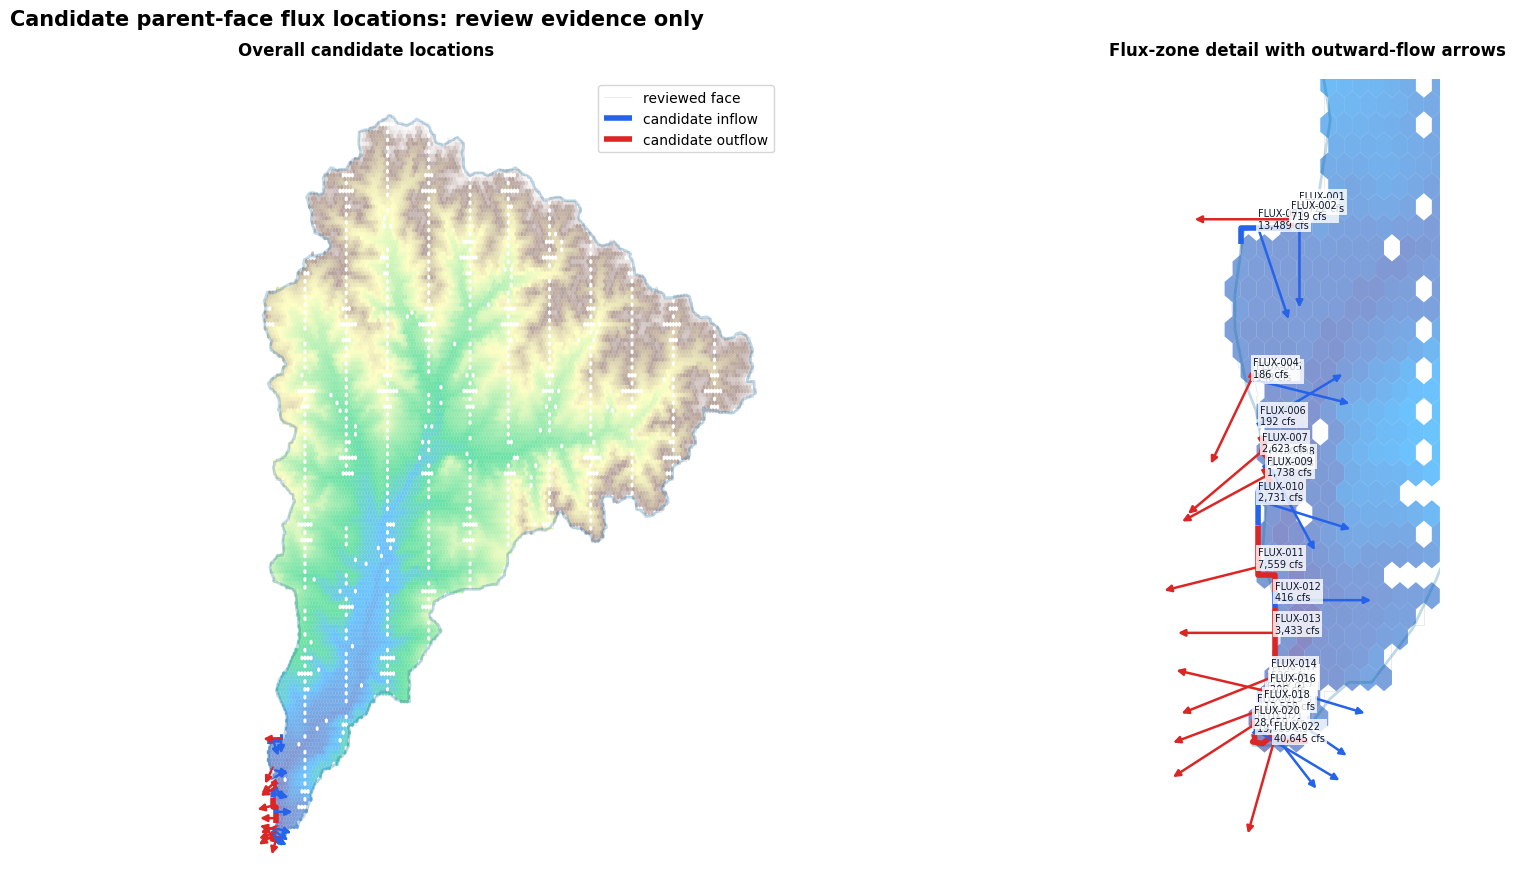

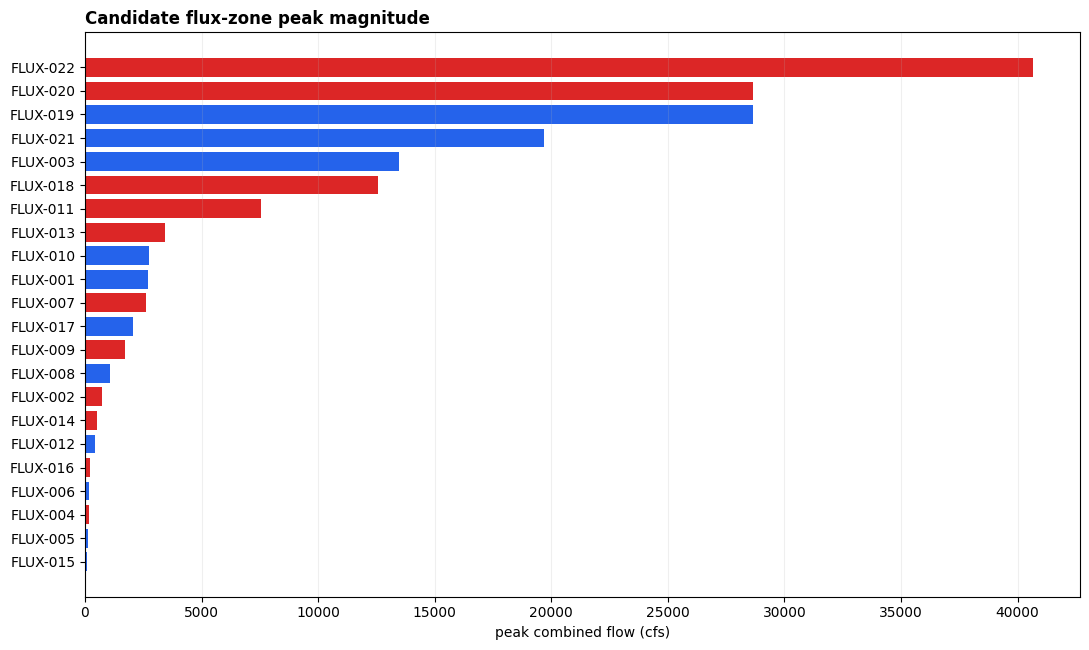

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))


def draw_flux_review(ax, *, label_zones=False):
    child_terrain = parent_terrain.loc[child_terrain_mask]
    ax.hexbin(
        child_terrain.geometry.x,
        child_terrain.geometry.y,
        C=child_terrain["minimum_terrain_elevation"],
        reduce_C_function=np.mean,
        gridsize=160,
        mincnt=1,
        cmap="terrain",
        linewidths=0,
        alpha=0.58,
    )
    preflight.child_boundary.plot(
        ax=ax,
        facecolor="none",
        edgecolor="#0369a1",
        alpha=0.25,
        linewidth=2.0,
    )
    flux.faces[~flux.faces["significant"]].plot(
        ax=ax,
        color="#94a3b8",
        linewidth=0.6,
        alpha=0.25,
        label="reviewed face",
    )
    for direction, frame in flux.zones.groupby("dominant_direction"):
        color = "#dc2626" if direction == "outflow" else "#2563eb"
        frame.plot(
            ax=ax,
            color=color,
            linewidth=4.0,
            label=f"candidate {direction}",
        )
        for row in frame.itertuples(index=False):
            point = row.geometry.interpolate(0.5, normalized=True)
            scale = max(preflight.base_cell_size * 6.0, 800.0)
            ax.annotate(
                "",
                xy=(point.x + row.arrow_dx * scale, point.y + row.arrow_dy * scale),
                xytext=(point.x, point.y),
                arrowprops={"arrowstyle": "-|>", "color": color, "lw": 1.8},
            )
            if label_zones:
                ax.text(
                    point.x,
                    point.y,
                    f"{row.zone_id}\n{row.peak_abs_flow:,.0f} cfs",
                    fontsize=7,
                    color="#0f172a",
                    bbox={
                        "facecolor": "white",
                        "alpha": 0.8,
                        "edgecolor": "none",
                        "pad": 1.5,
                    },
                )
    ax.set_aspect("equal")
    ax.set_axis_off()


draw_flux_review(axes[0])
axes[0].set_title("Overall candidate locations", loc="left", weight="bold")
axes[0].legend(loc="upper right")

draw_flux_review(axes[1], label_zones=True)
zone_min_x, zone_min_y, zone_max_x, zone_max_y = flux.zones.total_bounds
zone_width = zone_max_x - zone_min_x
zone_height = zone_max_y - zone_min_y
zone_pad = max(preflight.base_cell_size * 8.0, max(zone_width, zone_height) * 0.12)
axes[1].set_xlim(zone_min_x - zone_pad, zone_max_x + zone_pad)
axes[1].set_ylim(zone_min_y - zone_pad, zone_max_y + zone_pad)
axes[1].set_title("Flux-zone detail with outward-flow arrows", loc="left", weight="bold")

fig.suptitle(
    "Candidate parent-face flux locations: review evidence only",
    x=0.01,
    ha="left",
    fontsize=15,
    weight="bold",
)
plt.tight_layout()
plt.show()

ordered = flux.zones.sort_values("peak_abs_flow")
fig, ax = plt.subplots(figsize=(11, max(5, len(ordered) * 0.3)))
bar_colors = ordered["dominant_direction"].map(
    {"inflow": "#2563eb", "outflow": "#dc2626"}
)
ax.barh(ordered["zone_id"], ordered["peak_abs_flow"], color=bar_colors)
ax.set_title("Candidate flux-zone peak magnitude", loc="left", weight="bold")
ax.set_xlabel("peak combined flow (cfs)")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

## Next Steps - boundary conditions remain unresolved

The geometry workflow ends here. A separate reviewed workflow must decide which artificial-cut locations require forcing, select the correct hydraulic type, source and synchronize parent time series, offset/trim BC lines so adjacent records cannot bind the same face, and validate the breakout against the parent. Existing parent BCs are not automatically transferable merely because their unsteady rows were preserved.

In [9]:
next_steps = flux.zones[[
    "zone_id", "dominant_direction", "face_count", "peak_abs_flow", "absolute_volume_fraction"
]].copy()
next_steps.insert(0, "proposed_breakout_location", True)
next_steps["proposed_bc_type"] = "TBD - future boundary-method workflow"
next_steps["time_series_source"] = "TBD - derive from parent p08 after method approval"
next_steps["applied_in_this_notebook"] = False

forcing_register = pd.DataFrame(
    [
        {"input": "Source unsteady boundary rows", "status": "Cloned byte-for-byte; not adapted to child", "future_decision": "Determine applicability/location"},
        {"input": "Rain-on-grid precipitation", "status": "Contained in cloned unsteady input", "future_decision": "Verify DSS path and forcing equivalence before any run"},
        {"input": "Candidate child cut-face zones", "status": f"{len(next_steps)} locations mapped; none authored", "future_decision": "Choose type and parent-derived time series"},
        {"input": "Hydraulic simulation", "status": "Not run", "future_decision": "Run only after independent BC review"},
    ]
)
display(forcing_register)
display(next_steps)
assert not next_steps["applied_in_this_notebook"].any()

,input,status,future_decision
0,Source unsteady boundary rows,Cloned byte-for-byte; not adapted to child,Determine applicability/location
1,Rain-on-grid precipitation,Contained in cloned unsteady input,Verify DSS path and forcing equivalence before any run
2,Candidate child cut-face zones,22 locations mapped; none authored,Choose type and parent-derived time series
3,Hydraulic simulation,Not run,Run only after independent BC review


,proposed_breakout_location,zone_id,dominant_direction,face_count,peak_abs_flow,absolute_volume_fraction,proposed_bc_type,time_series_source,applied_in_this_notebook
0,True,FLUX-001,inflow,1,2721.547119,0.006661,TBD - future boundary-method workflow,TBD - derive from parent p08 after method approval,False
1,True,FLUX-002,outflow,1,719.005493,0.002386,TBD - future boundary-method workflow,TBD - derive from parent p08 after method approval,False
2,True,FLUX-003,inflow,4,13488.601944,0.033551,TBD - future boundary-method workflow,TBD - derive from parent p08 after method approval,False
3,True,FLUX-004,outflow,1,185.765167,0.000559,TBD - future boundary-method workflow,TBD - derive from parent p08 after method approval,False
4,True,FLUX-005,inflow,1,147.977173,0.000606,TBD - future boundary-method workflow,TBD - derive from parent p08 after method approval,False
5,True,FLUX-006,inflow,1,191.552246,0.000686,TBD - future boundary-method workflow,TBD - derive from parent p08 after method approval,False
6,True,FLUX-007,outflow,6,2623.394371,0.006990,TBD - future boundary-method workflow,TBD - derive from parent p08 after method approval,False
7,True,FLUX-008,inflow,1,1055.620850,0.004441,TBD - future boundary-method workflow,TBD - derive from parent p08 after method approval,False
8,True,FLUX-009,outflow,2,1737.797363,0.005773,TBD - future boundary-method workflow,TBD - derive from parent p08 after method approval,False
9,True,FLUX-010,inflow,4,2730.677063,0.022034,TBD - future boundary-method workflow,TBD - derive from parent p08 after method approval,False
